
# Student Stress Dataset Analysis
### Preprocesamiento, Discretización y Ranking de Características

Este notebook implementa un flujo completo de **preprocesamiento y selección de características** usando el dataset:

**Student Stress Monitoring Dataset**

## Objetivos

1. Cargar el dataset desde Kaggle
2. Analizar su estructura
3. Tratar valores faltantes
4. Eliminar outliers
5. Escalar características
6. Discretizar variables clave
7. Rankear variables usando **Información Mutua**
8. Visualizar resultados



## 1. Librerías
Se importan las librerías necesarias para manejo de datos, visualización y aprendizaje automático.


In [1]:

# pip install kagglehub[pandas-datasets] scikit-learn pandas numpy matplotlib seaborn

import kagglehub
import pandas as pd
import numpy as np
import glob

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\frida\AppData\Local\pypoetry\Cache\virtualenvs\recocimiento_de_patrones-3a7zzQ48-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Carga del Dataset

Se descarga el dataset desde Kaggle usando **kagglehub** y se localiza automáticamente el archivo CSV.


In [2]:

path = kagglehub.dataset_download(
    "mdsultanulislamovi/student-stress-monitoring-datasets"
)

print("Dataset path:", path)

csv_files = glob.glob(path + "/**/*.csv", recursive=True)
print("CSV files:", csv_files)

df = pd.read_csv(csv_files[0])

df.head()


Dataset path: C:\Users\frida\.cache\kagglehub\datasets\mdsultanulislamovi\student-stress-monitoring-datasets\versions\1
CSV files: ['C:\\Users\\frida\\.cache\\kagglehub\\datasets\\mdsultanulislamovi\\student-stress-monitoring-datasets\\versions\\1\\StressLevelDataset.csv', 'C:\\Users\\frida\\.cache\\kagglehub\\datasets\\mdsultanulislamovi\\student-stress-monitoring-datasets\\versions\\1\\Stress_Dataset.csv']


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



## 3. Exploración Inicial
Mostramos información general del dataset.


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [4]:

df.describe()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000



## 4. Tratamiento de Datos Faltantes
Se identifican valores faltantes y se reemplazan con la **media de cada columna numérica**.


In [5]:

print("Valores faltantes por columna:")
print(df.isnull().sum())

df = df.fillna(df.mean(numeric_only=True))


Valores faltantes por columna:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64



## 5. Eliminación de Outliers

Se utiliza el método **IQR (Interquartile Range)**:

IQR = Q3 - Q1

Los valores fuera de:
[Q1 - 1.5*IQR , Q3 + 1.5*IQR]
son considerados outliers.


In [6]:

def remove_outliers_iqr(data):

    df_clean = data.copy()

    for col in df_clean.select_dtypes(include=np.number).columns:

        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

    return df_clean


df = remove_outliers_iqr(df)

print("Shape after removing outliers:", df.shape)


Shape after removing outliers: (645, 21)



## 6. Escalamiento de Características

Se aplica **MinMaxScaler** para normalizar los datos al rango [0,1].


In [7]:

scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,0.666667,0.666667,0.0,0.407407,0.4,0.0,0.4,0.8,0.333333,0.666667,...,0.4,0.50,0.333333,0.50,0.6,0.5,0.666667,0.666667,0.4,0.5
2,0.571429,0.600000,1.0,0.518519,0.4,0.0,0.4,0.4,0.333333,0.333333,...,0.4,0.25,0.666667,0.50,0.4,0.5,0.666667,0.333333,0.4,0.5
3,0.761905,0.400000,1.0,0.555556,0.8,1.0,0.2,0.6,1.000000,0.333333,...,0.4,0.25,1.000000,0.00,0.8,0.0,1.000000,1.000000,1.0,1.0
6,0.190476,0.866667,0.0,0.222222,0.2,0.5,0.8,0.2,0.000000,1.000000,...,0.8,1.00,0.000000,0.75,0.2,1.0,0.333333,0.333333,0.2,0.0
7,0.809524,0.100000,1.0,0.814815,0.8,1.0,0.2,1.0,0.666667,0.000000,...,0.2,0.00,0.666667,0.25,0.8,0.0,1.000000,1.000000,1.0,1.0



## 7. Discretización de Variables

Se discretizan las variables:

- anxiety_level
- self_esteem
- depression

en tres categorías:

- low
- medium
- high


In [8]:

def discretize_three_levels(column):
    return pd.qcut(column, q=3, labels=["low","medium","high"])

df["anxiety_level"] = discretize_three_levels(df["anxiety_level"])
df["self_esteem"] = discretize_three_levels(df["self_esteem"])
df["depression"] = discretize_three_levels(df["depression"])

df[["anxiety_level","self_esteem","depression"]].head()


,anxiety_level,self_esteem,depression
0,high,low,medium
2,high,low,high
3,high,low,high
6,low,medium,low
7,high,low,high



## 8. Conversión a Variables Numéricas
Para poder aplicar algoritmos de aprendizaje automático se convierten las etiquetas categóricas a valores numéricos.


In [9]:

mapping = {"low":0,"medium":1,"high":2}

df["depression"] = df["depression"].map(mapping)
df["anxiety_level"] = df["anxiety_level"].map(mapping)
df["self_esteem"] = df["self_esteem"].map(mapping)

df.head()


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,2,0,0.0,1,0.4,0.0,0.4,0.8,0.333333,0.666667,...,0.4,0.50,0.333333,0.50,0.6,0.5,0.666667,0.666667,0.4,0.5
2,2,0,1.0,2,0.4,0.0,0.4,0.4,0.333333,0.333333,...,0.4,0.25,0.666667,0.50,0.4,0.5,0.666667,0.333333,0.4,0.5
3,2,0,1.0,2,0.8,1.0,0.2,0.6,1.000000,0.333333,...,0.4,0.25,1.000000,0.00,0.8,0.0,1.000000,1.000000,1.0,1.0
6,0,1,0.0,0,0.2,0.5,0.8,0.2,0.000000,1.000000,...,0.8,1.00,0.000000,0.75,0.2,1.0,0.333333,0.333333,0.2,0.0
7,2,0,1.0,2,0.8,1.0,0.2,1.0,0.666667,0.000000,...,0.2,0.00,0.666667,0.25,0.8,0.0,1.000000,1.000000,1.0,1.0



## 9. Ranking de Características con Información Mutua

La **Información Mutua** mide cuánto conocimiento sobre una variable reduce la incertidumbre sobre otra.

En este caso se usa para evaluar qué características ayudan más a predecir **depression**.


In [10]:

X = df.drop(columns=["depression"])
y = df["depression"]

X = X.select_dtypes(include=np.number)

mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

mi_scores


future_career_concerns          0.516037
headache                        0.511233
bullying                        0.504189
academic_performance            0.503138
blood_pressure                  0.491439
sleep_quality                   0.486952
safety                          0.481775
basic_needs                     0.459660
stress_level                    0.456378
teacher_student_relationship    0.454496
breathing_problem               0.275249
noise_level                     0.263955
peer_pressure                   0.258317
study_load                      0.254236
extracurricular_activities      0.254120
living_conditions               0.249377
social_support                  0.165965
mental_health_history           0.138842
dtype: float64


## 10. Visualización del Ranking de Información Mutua


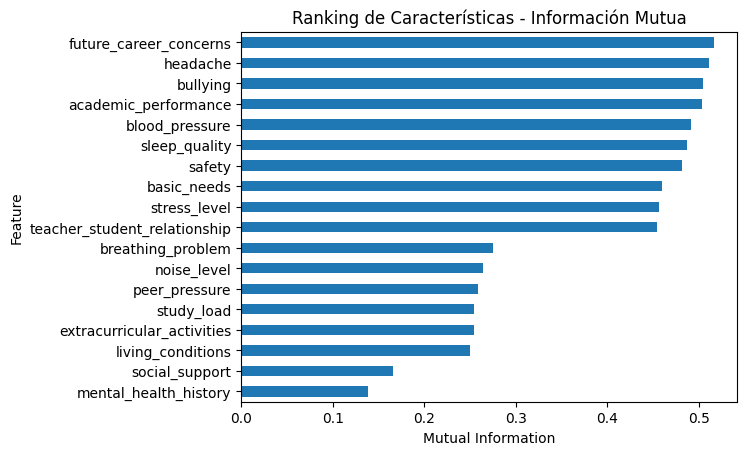

In [11]:

plt.figure()

mi_scores.sort_values().plot(kind="barh")

plt.title("Ranking de Características - Información Mutua")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")

plt.show()



## 11. Histogramas de Variables Discretizadas
Estos histogramas permiten visualizar la distribución de los niveles discretizados.


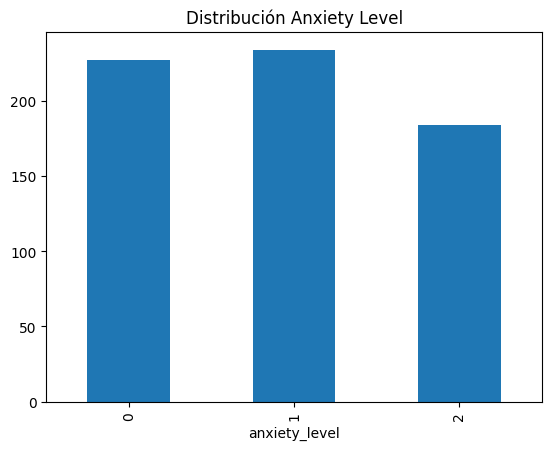

In [12]:

plt.figure()
df["anxiety_level"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución Anxiety Level")
plt.show()


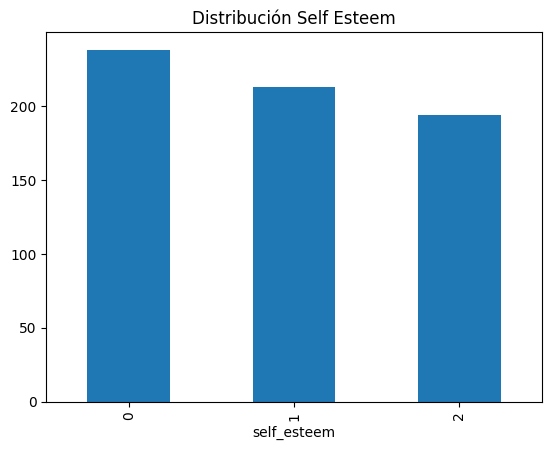

In [13]:

plt.figure()
df["self_esteem"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución Self Esteem")
plt.show()


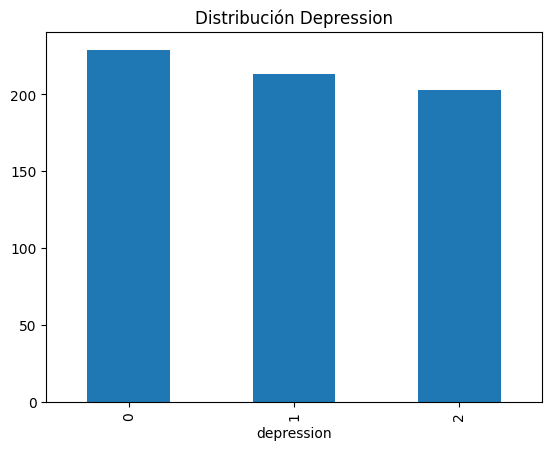

In [14]:

plt.figure()
df["depression"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución Depression")
plt.show()



## 12. Heatmap de Correlación

El heatmap permite visualizar relaciones entre variables numéricas.


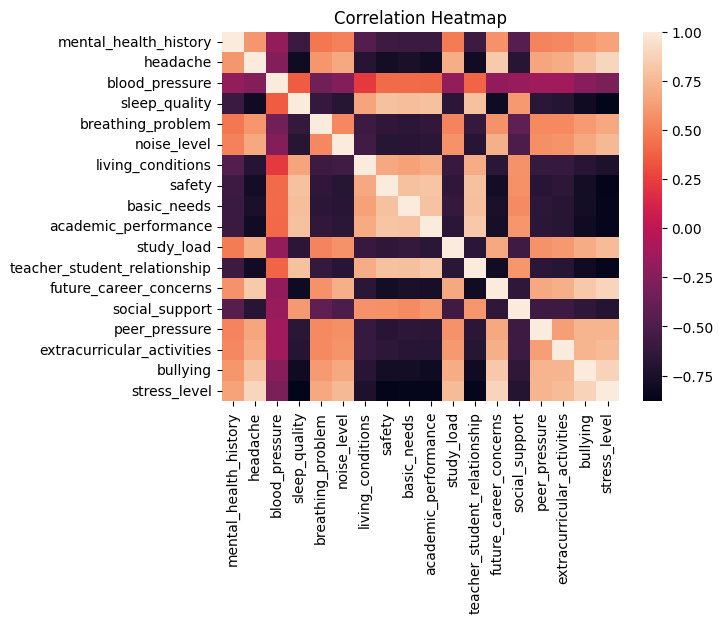

In [15]:

plt.figure()

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=False)

plt.title("Correlation Heatmap")

plt.show()



## 13. Interpretación de Resultados

A partir del ranking de **Información Mutua** podemos identificar qué variables tienen mayor influencia en los niveles de depresión.

Las variables con mayor MI aportan más información para clasificar correctamente los niveles de depresión.

Esto permite:

- reducir dimensionalidad
- mejorar modelos predictivos
- identificar factores de riesgo relacionados con estrés estudiantil
